In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("/content/processed_zomato_dataset .....csv", on_bad_lines='skip', engine='python')

df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,1.068510,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",1.651330,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,1.090058,080 41714161,Banashankari,Casual Dining,"Chinese, North Indian, Thai",1.651330,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,1.325287,+91 9663487993,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",1.651330,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,-0.165096,+91 9620009302,Banashankari,Quick Bites,"South Indian, North Indian",-0.625755,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,-0.025036,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"North Indian, Rajasthani",0.740496,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5579 entries, 0 to 5578
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          5579 non-null   object 
 1   address                      5578 non-null   object 
 2   name                         5578 non-null   object 
 3   online_order                 5578 non-null   object 
 4   book_table                   5578 non-null   object 
 5   rate                         4761 non-null   object 
 6   votes                        5578 non-null   float64
 7   phone                        5484 non-null   object 
 8   location                     5578 non-null   object 
 9   rest_type                    5555 non-null   object 
 10  cuisines                     5574 non-null   object 
 11  approx_cost(for two people)  5578 non-null   float64
 12  reviews_list                 5578 non-null   object 
 13  menu_item         

In [ ]:
df.describe()

,votes,approx_cost(for two people)
count,5578.000000,5578.000000
mean,-0.049821,-0.059572
std,0.699992,0.991701
min,-0.323112,-1.809839
25%,-0.312338,-0.853464
50%,-0.263856,-0.170338
75%,-0.086087,0.512788
max,8.762833,2.562164


In [ ]:
df['Cuisine_Count'] = df['cuisines'].astype(str).apply(lambda x: len(x.split(',')))

In [ ]:
df[['cuisines','Cuisine_Count']].head()

,cuisines,Cuisine_Count
0,"North Indian, Mughlai, Chinese",3
1,"Chinese, North Indian, Thai",3
2,"Cafe, Mexican, Italian",3
3,"South Indian, North Indian",2
4,"North Indian, Rajasthani",2


In [ ]:
df['Cost_Category'] = pd.cut(
    df['approx_cost(for two people)'],
    bins=[0,500,1000,5000],
    labels=['Low','Medium','High']
)

In [ ]:
df[['approx_cost(for two people)','Cost_Category']].head()

,approx_cost(for two people),Cost_Category
0,1.651330,Low
1,1.651330,Low
2,1.651330,Low
3,-0.625755,NaN
4,0.740496,Low


In [ ]:
df['rate'] = df['rate'].replace('NEW', np.nan) # Replace 'NEW' with NaN
df['rate'] = df['rate'].replace('-', np.nan) # Replace '-' with NaN
df['rate'] = df['rate'].apply(lambda x: float(x.split('/')[0]) if isinstance(x, str) else x) # Extract numeric part and convert
df['Popularity_Score'] = df['votes'] * df['rate']

In [ ]:
df[['votes','rate','Popularity_Score']].head()

,votes,rate,Popularity_Score
0,1.068510,4.1,4.380891
1,1.090058,4.1,4.469236
2,1.325287,3.8,5.036089
3,-0.165096,3.7,-0.610854
4,-0.025036,3.8,-0.095136


In [ ]:
df['Online_Presence'] = (
    (df['online_order'].map({'Yes':1,'No':0})) +
    (df['book_table'].map({'Yes':1,'No':0}))
)

In [ ]:
df[['online_order','book_table','Online_Presence']].head()

,online_order,book_table,Online_Presence
0,Yes,Yes,2.0
1,Yes,No,1.0
2,Yes,No,1.0
3,No,No,0.0
4,No,No,0.0


In [ ]:
location_rating = df.groupby('location')['rate'].mean()

df['Location_Popularity'] = df['location'].map(location_rating)

In [ ]:
df[['location','Location_Popularity']].head()

,location,Location_Popularity
0,Banashankari,3.636585
1,Banashankari,3.636585
2,Banashankari,3.636585
3,Banashankari,3.636585
4,Basavanagudi,3.692081


In [ ]:
encoder = LabelEncoder()

df['online_order'] = encoder.fit_transform(df['online_order'])

df['book_table'] = encoder.fit_transform(df['book_table'])

In [ ]:
df = pd.get_dummies(df,
                    columns=['Cost_Category'],
                    drop_first=True)

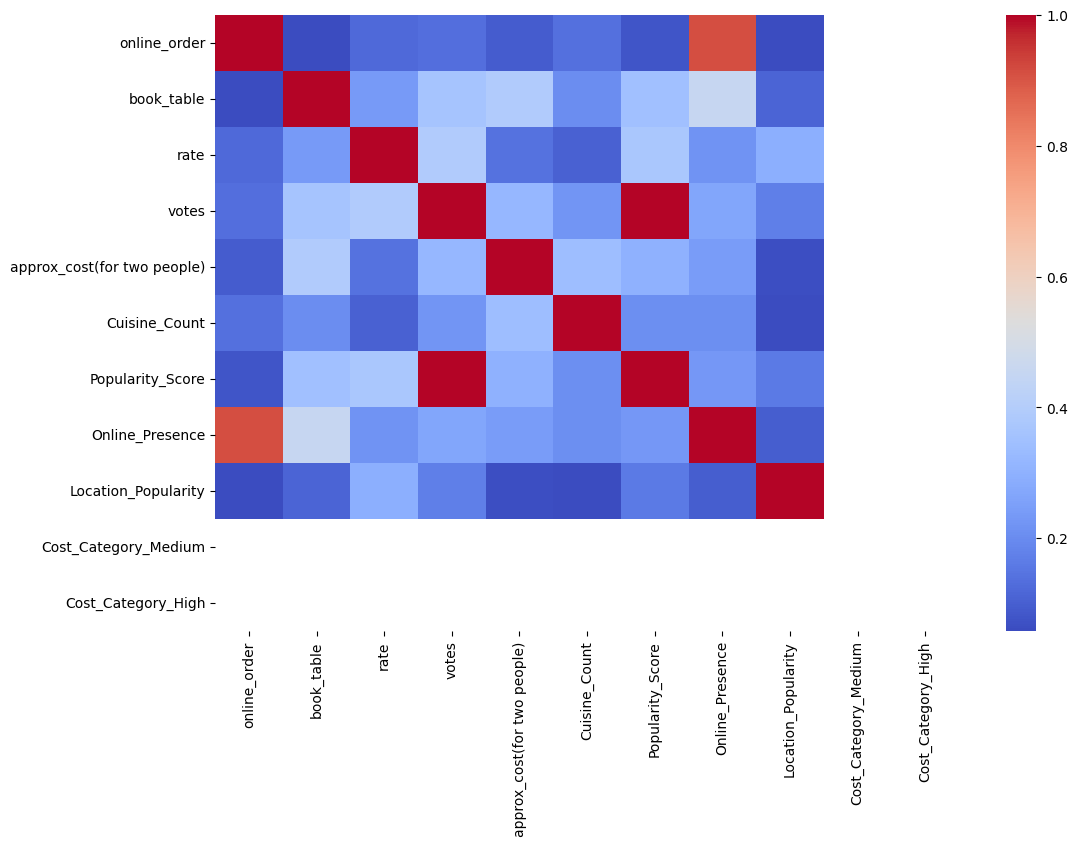

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
corr = df.corr(numeric_only=True)

corr['rate'].sort_values(ascending=False)

,rate
rate,1.000000
votes,0.390322
Popularity_Score,0.371282
Location_Popularity,0.291685
book_table,0.234988
Online_Presence,0.216725
approx_cost(for two people),0.141433
online_order,0.123897
Cuisine_Count,0.106063
Cost_Category_Medium,NaN


In [ ]:
df.to_csv("zomato_feature_engineered.csv",
          index=False)